<a href="https://colab.research.google.com/github/Mohammad-Salhi/mohammad/blob/main/Welcome_to_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [103]:
import pandas as pd
import numpy as np

In [104]:
df = pd.read_csv("IMDB_Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [105]:
df.info()
df['sentiment'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


,count
sentiment,
positive,25000
negative,25000


In [106]:
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

In [107]:
df = df.dropna()

In [108]:
print(df.isnull().sum())

review       0
sentiment    0
dtype: int64


In [109]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['review'])

In [110]:
y = df['sentiment']

In [111]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [112]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [113]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8988


In [114]:
test = ["This movie is very bad"]
test_vec = vectorizer.transform(test)

prediction = model.predict(test_vec)

print(prediction)

[0]


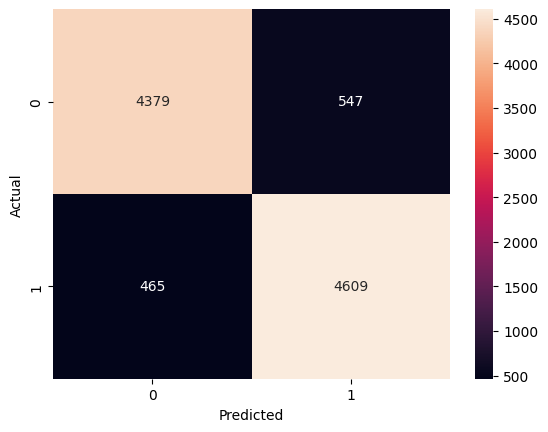

In [115]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [116]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.89      0.90      4926
           1       0.89      0.91      0.90      5074

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [117]:
from sklearn.naive_bayes import MultinomialNB

model2 = MultinomialNB()
model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

from sklearn.metrics import accuracy_score
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred2))

Naive Bayes Accuracy: 0.8656


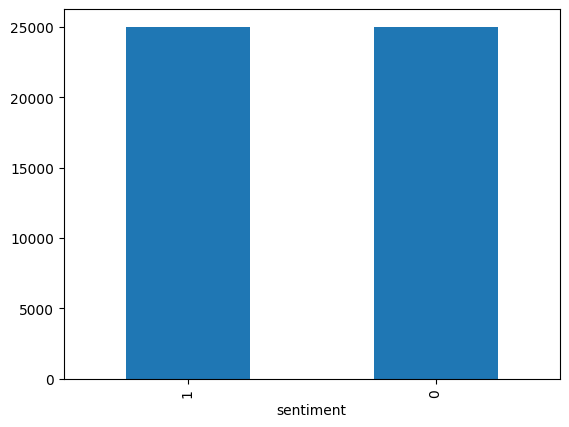

In [118]:
df['sentiment'].value_counts().plot(kind='bar')
plt.show()

In [119]:
def predict_sentiment(text):
    text_vec = vectorizer.transform([text])
    pred = model.predict(text_vec)

    if pred[0] == 1:
        return "Positive 😊"
    else:
        return "Negative 😡"

In [120]:
print(predict_sentiment("This movie is fantastic and I loved it"))
print(predict_sentiment("This movie is terrible and boring"))

Positive 😊
Negative 😡


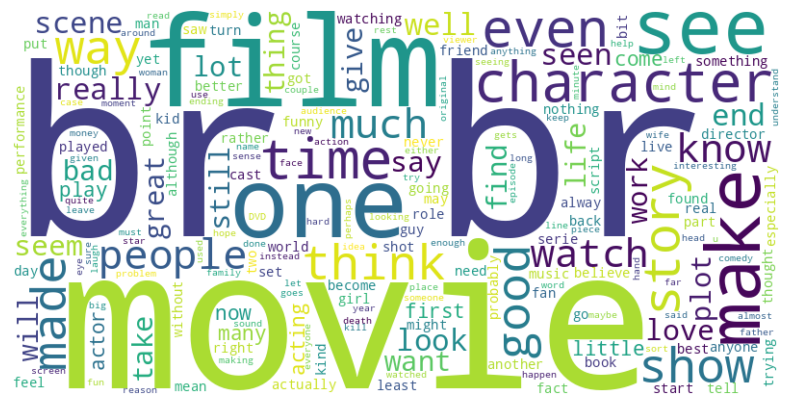

In [121]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['review'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [122]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Logistic Regression
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)
pred_lr = model_lr.predict(X_test)

# Naive Bayes
model_nb = MultinomialNB()
model_nb.fit(X_train, y_train)
pred_nb = model_nb.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, pred_lr))
print("Naive Bayes Accuracy:", accuracy_score(y_test, pred_nb))

Logistic Regression Accuracy: 0.8988
Naive Bayes Accuracy: 0.8656


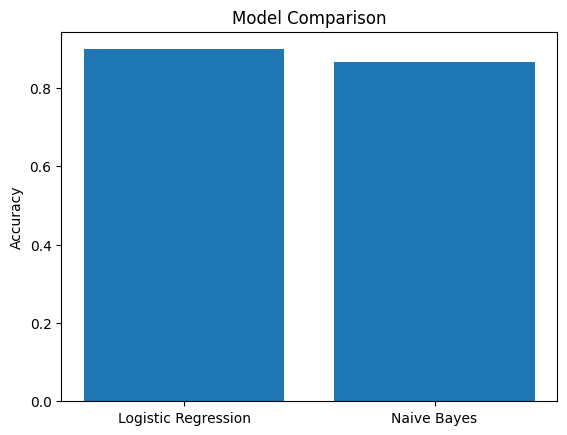

In [123]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Naive Bayes']
accuracy = [
    accuracy_score(y_test, pred_lr),
    accuracy_score(y_test, pred_nb)
]

plt.bar(models, accuracy)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

In [124]:
print("Logistic Regression Accuracy:", accuracy[0])
print("Naive Bayes Accuracy:", accuracy[1])

Logistic Regression Accuracy: 0.8988
Naive Bayes Accuracy: 0.8656


In [125]:
if accuracy[0] > accuracy[1]:
    print("Best Model: Logistic Regression 🏆")
else:
    print("Best Model: Naive Bayes 🏆")

Best Model: Logistic Regression 🏆


In [126]:
print("Project completed successfully: Sentiment Analysis using Machine Learning")

Project completed successfully: Sentiment Analysis using Machine Learning


In [127]:
def chatbot():
    print("🤖 Sentiment Analysis Bot is running...")
    print("Type 'exit' to stop\n")

    while True:
        user_input = input("Enter a movie review: ")

        if user_input.lower() == 'exit':
            print("Bot stopped 👋")
            break

        text_vec = vectorizer.transform([user_input])
        pred = model.predict(text_vec)

        if pred[0] == 1:
            print("👉 Positive 😊\n")
        else:
            print("👉 Negative 😡\n")

In [ ]:
chatbot()

🤖 Sentiment Analysis Bot is running...
Type 'exit' to stop

